In [ ]:
# === Setup ===
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Parameters
sequence_length = 30
forecast_day = pd.to_datetime("2025-04-30")
cutoff_date = forecast_day - pd.Timedelta(days=7)

# Load data
df = pd.read_csv(r"C:\Users\jaskew\Documents\project_repository\notebooks\observationEventForecasting\DataPreprocessing\temporalData.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['indicator', 'date']).reset_index(drop=True)

# Features to include
feature_cols = [
    'rolling_seen_ratio_14d',
    'rolling_seen_std_14d',
    'volatility_ratio',
    'seen_streak',
    'rolling_obs_14d',
    'obs_ratio_spike',
    'recent_drop_flag'
]

# Clean and verified seen gap stats block
gap_input = df[['indicator', 'date', 'seen']].copy()
gap_input['date'] = pd.to_datetime(gap_input['date'])
gap_input = gap_input.set_index('date')

def seen_gap_stats(series):
    gaps = series[series == 1].index.to_series().diff().dropna().dt.days
    return pd.Series({
        'seen_gap_mean': gaps.mean() if not gaps.empty else 0.0,
        'seen_gap_std': gaps.std() if not gaps.empty else 0.0
    })

# Pivot to wide format
gap_stats = (
    gap_input.groupby('indicator')['seen']
    .apply(seen_gap_stats)
    .reset_index()
    .pivot(index='indicator', columns='level_1', values='seen')
    .reset_index()
    .rename_axis(None, axis=1)
)

df = df.merge(gap_stats, on='indicator', how='left')

# === Forecast and Labeling ===
results = []
predictions = []
indicators_to_run = df['indicator'].value_counts().index

for indicator_id in indicators_to_run:
    data = df[df['indicator'] == indicator_id].sort_values('date').reset_index(drop=True)
    past_data = data[data['date'] < cutoff_date].copy()

    if len(past_data) < sequence_length + 1:
        continue

    # Drop rows with missing values
    past_data = past_data.dropna(subset=feature_cols + ['seen'])
    if past_data.empty:
        continue

    # Normalize features
    scaler = MinMaxScaler()
    past_data[feature_cols] = scaler.fit_transform(past_data[feature_cols])

    # Build sequences
    X, y = [], []
    for i in range(len(past_data) - sequence_length):
        X_seq = past_data[feature_cols].iloc[i:i+sequence_length].values
        y_seq = past_data['seen'].iloc[i + sequence_length]
        X.append(X_seq)
        y.append(y_seq)

    if not X:
        continue

    X = np.array(X).astype(np.float32)
    y = np.array(y).astype(np.float32)

    # Train LSTM
    X_train, _, y_train, _ = train_test_split(X, y, test_size=0.1, random_state=42)
    model = Sequential([
        Input(shape=(sequence_length, len(feature_cols))),
        LSTM(32),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy')
    model.fit(X_train, y_train, epochs=10, batch_size=8, verbose=0)

    # Predict using most recent 30 days
    latest_seq = past_data[feature_cols].iloc[-sequence_length:].values.reshape(1, sequence_length, len(feature_cols)).astype(np.float32)
    prediction_prob = model.predict(latest_seq)[0][0]
    prediction = int(prediction_prob > 0.5)

    results.append({
        "indicator": indicator_id,
        "prediction": prediction,
        "confidence": prediction_prob
    })

results_df = pd.DataFrame(results)

# Merge prediction results back to metadata for rule labeling
enriched = df[df['date'] < cutoff_date].groupby('indicator').tail(1).drop_duplicates('indicator')
results_df = results_df.merge(
    enriched[['indicator', 'seen_score', 'unseen_risk', 'high_activity_not_seen_ratio', 'seen_gap_mean', 'rolling_seen_ratio_14d', 'seen_streak']],
    on='indicator', how='left'
)

# === Updated Likelihood Scoring Model (based on external pressure signals) ===
def likelihood_score(row):
    try:
        unseen_risk = max(0, min(row['unseen_risk'], 150))
        ext_ratio = max(0, min(row['high_activity_not_seen_ratio'], 1))
        seen_gap = max(0, min(row['seen_gap_mean'], 30))

        score = 0
        score += min(unseen_risk / 100, 1) * 0.45
        score += ext_ratio * 0.45
        score += max(0, (1 - (seen_gap - 9) / 21)) * 0.10 if seen_gap > 9 else 0.10

        return round(score, 3)
    except:
        return 0.0


results_df['likelihood_score'] = results_df.apply(likelihood_score, axis=1)

# === Final Output: Most Likely to Be Seen Indicators (model failed but score is high) ===
likely_indicators = results_df[(results_df['prediction'] == 0) & (results_df['likelihood_score'] >= 0.7)]
likely_indicators

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 735ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 549ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 601ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [72]:
current_seen_data = df[(df['date'] == '2025-04-30') & (df['seen'] == 1)]
current_seen_data

,indicator,date,seen,cumulative_seen,days_since_last_seen_x,seen_streak,rolling_seen_ratio_14d,rolling_seen_std_14d,high_activity_not_seen_ratio_14d,low_activity_seen_ratio_14d,...,std_seen_interval,days_since_last_seen_y,high_activity_not_seen_count,high_activity_not_seen_ratio,low_activity_seen_count,low_activity_seen_ratio,seen_score,unseen_risk,seen_gap_mean,seen_gap_std
1087,104.21.48.1,2025-04-30,1,96,0.0,38,1.000000,0.000000,0.000000,0.285714,...,0.203058,0,0,0.000000,7,0.057851,80.782645,4.400000,1.020833,0.204124
1208,104.21.54.132,2025-04-30,1,66,0.0,6,0.857143,0.363137,0.000000,0.642857,...,0.585445,0,0,0.000000,0,0.000000,51.185950,7.400000,1.257576,0.589931
3386,156.146.63.162,2025-04-30,1,11,0.0,1,0.071429,0.267261,0.928571,0.000000,...,8.616264,1,110,0.909091,0,0.000000,8.145455,98.009091,8.600000,9.082339
4354,156.146.63.170,2025-04-30,1,14,0.0,1,0.071429,0.267261,0.928571,0.000000,...,6.764859,1,107,0.884298,0,0.000000,10.285124,93.129752,7.923077,7.041088
4475,156.146.63.171,2025-04-30,1,19,0.0,1,0.142857,0.363137,0.857143,0.000000,...,4.403982,1,102,0.842975,0,0.000000,14.051240,87.797521,5.777778,4.531661
5564,156.146.63.180,2025-04-30,1,13,0.0,1,0.214286,0.425815,0.071429,0.000000,...,5.649484,1,108,0.892562,0,0.000000,9.771901,97.956198,6.500000,5.900693
5685,156.146.63.181,2025-04-30,1,18,0.0,1,0.214286,0.425815,0.785714,0.000000,...,7.538597,1,103,0.851240,0,0.000000,13.338017,91.423967,6.588235,7.770608
6290,162.142.125.247,2025-04-30,1,101,0.0,2,0.928571,0.267261,0.000000,0.357143,...,0.501737,0,0,0.000000,19,0.157025,77.148760,0.600000,1.188119,0.504239
6411,162.142.125.255,2025-04-30,1,98,0.0,3,0.928571,0.267261,0.000000,0.214286,...,0.505694,0,0,0.000000,29,0.239669,74.209091,0.400000,1.224490,0.508294
7137,172.240.108.68,2025-04-30,1,98,0.0,10,0.928571,0.267261,0.000000,0.214286,...,0.593330,0,0,0.000000,9,0.074380,75.809091,0.600000,1.214286,0.596381


In [73]:
missed_indicators = predicted_seen.merge(
    current_seen_data,
    how='outer',
    on='indicator',
    indicator=True
)
missed_indicators = missed_indicators[missed_indicators['_merge'] != 'both']
missed_indicators

,indicator,forecast date,predicted seen,confidence,date,seen,cumulative_seen,days_since_last_seen_x,seen_streak,rolling_seen_ratio_14d,...,days_since_last_seen_y,high_activity_not_seen_count,high_activity_not_seen_ratio,low_activity_seen_count,low_activity_seen_ratio,seen_score,unseen_risk,seen_gap_mean,seen_gap_std,_merge
2,104.21.61.32,2025-04-30,Yes,0.519,NaT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
3,156.146.63.162,NaN,NaN,NaN,2025-04-30,1.0,11.0,0.0,1.0,0.071429,...,1.0,110.0,0.909091,0.0,0.0,8.145455,98.009091,8.600000,9.082339,right_only
4,156.146.63.170,NaN,NaN,NaN,2025-04-30,1.0,14.0,0.0,1.0,0.071429,...,1.0,107.0,0.884298,0.0,0.0,10.285124,93.129752,7.923077,7.041088,right_only
5,156.146.63.171,NaN,NaN,NaN,2025-04-30,1.0,19.0,0.0,1.0,0.142857,...,1.0,102.0,0.842975,0.0,0.0,14.051240,87.797521,5.777778,4.531661,right_only
6,156.146.63.180,NaN,NaN,NaN,2025-04-30,1.0,13.0,0.0,1.0,0.214286,...,1.0,108.0,0.892562,0.0,0.0,9.771901,97.956198,6.500000,5.900693,right_only
7,156.146.63.181,NaN,NaN,NaN,2025-04-30,1.0,18.0,0.0,1.0,0.214286,...,1.0,103.0,0.851240,0.0,0.0,13.338017,91.423967,6.588235,7.770608,right_only
8,162.142.125.242,2025-04-30,Yes,0.861,NaT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
12,178.175.129.37,NaN,NaN,NaN,2025-04-30,1.0,15.0,0.0,2.0,0.357143,...,1.0,106.0,0.876033,0.0,0.0,11.198347,104.903306,2.500000,1.870829,right_only
14,185.253.162.21,2025-04-30,Yes,0.513,NaT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
15,185.38.109.109,NaN,NaN,NaN,2025-04-30,1.0,18.0,0.0,2.0,0.428571,...,1.0,103.0,0.851240,0.0,0.0,13.538017,93.823967,6.705882,10.384873,right_only


In [74]:
false_positives = missed_indicators[missed_indicators['_merge'] == 'left_only']
false_positives

,indicator,forecast date,predicted seen,confidence,date,seen,cumulative_seen,days_since_last_seen_x,seen_streak,rolling_seen_ratio_14d,...,days_since_last_seen_y,high_activity_not_seen_count,high_activity_not_seen_ratio,low_activity_seen_count,low_activity_seen_ratio,seen_score,unseen_risk,seen_gap_mean,seen_gap_std,_merge
2,104.21.61.32,2025-04-30,Yes,0.519,NaT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
8,162.142.125.242,2025-04-30,Yes,0.861,NaT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
14,185.253.162.21,2025-04-30,Yes,0.513,NaT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
17,34.160.111.145,2025-04-30,Yes,0.849,NaT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only


In [89]:
false_negatives = missed_indicators[missed_indicators['_merge'] == 'right_only']
false_negatives

,indicator,forecast date,predicted seen,confidence,date,seen,cumulative_seen,days_since_last_seen_x,seen_streak,rolling_seen_ratio_14d,...,days_since_last_seen_y,high_activity_not_seen_count,high_activity_not_seen_ratio,low_activity_seen_count,low_activity_seen_ratio,seen_score,unseen_risk,seen_gap_mean,seen_gap_std,_merge
3,156.146.63.162,NaN,NaN,NaN,2025-04-30,1.0,11.0,0.0,1.0,0.071429,...,1.0,110.0,0.909091,0.0,0.0,8.145455,98.009091,8.600000,9.082339,right_only
4,156.146.63.170,NaN,NaN,NaN,2025-04-30,1.0,14.0,0.0,1.0,0.071429,...,1.0,107.0,0.884298,0.0,0.0,10.285124,93.129752,7.923077,7.041088,right_only
5,156.146.63.171,NaN,NaN,NaN,2025-04-30,1.0,19.0,0.0,1.0,0.142857,...,1.0,102.0,0.842975,0.0,0.0,14.051240,87.797521,5.777778,4.531661,right_only
6,156.146.63.180,NaN,NaN,NaN,2025-04-30,1.0,13.0,0.0,1.0,0.214286,...,1.0,108.0,0.892562,0.0,0.0,9.771901,97.956198,6.500000,5.900693,right_only
7,156.146.63.181,NaN,NaN,NaN,2025-04-30,1.0,18.0,0.0,1.0,0.214286,...,1.0,103.0,0.851240,0.0,0.0,13.338017,91.423967,6.588235,7.770608,right_only
12,178.175.129.37,NaN,NaN,NaN,2025-04-30,1.0,15.0,0.0,2.0,0.357143,...,1.0,106.0,0.876033,0.0,0.0,11.198347,104.903306,2.500000,1.870829,right_only
15,185.38.109.109,NaN,NaN,NaN,2025-04-30,1.0,18.0,0.0,2.0,0.428571,...,1.0,103.0,0.851240,0.0,0.0,13.538017,93.823967,6.705882,10.384873,right_only
16,192.124.249.112,NaN,NaN,NaN,2025-04-30,1.0,8.0,0.0,3.0,0.571429,...,1.0,113.0,0.933884,0.0,0.0,6.205785,115.088430,1.857143,1.463850,right_only
18,46.246.8.75,NaN,NaN,NaN,2025-04-30,1.0,14.0,0.0,1.0,0.142857,...,1.0,107.0,0.884298,0.0,0.0,10.285124,92.929752,7.615385,5.737863,right_only
19,46.246.8.96,NaN,NaN,NaN,2025-04-30,1.0,9.0,0.0,1.0,0.142857,...,1.0,112.0,0.925620,0.0,0.0,6.519008,98.461983,12.875000,7.679983,right_only


In [76]:
false_negatives_activity = df[df['indicator'].isin(false_negatives['indicator'])]
false_positives_activity = df[df['indicator'].isin(false_positives['indicator'])]


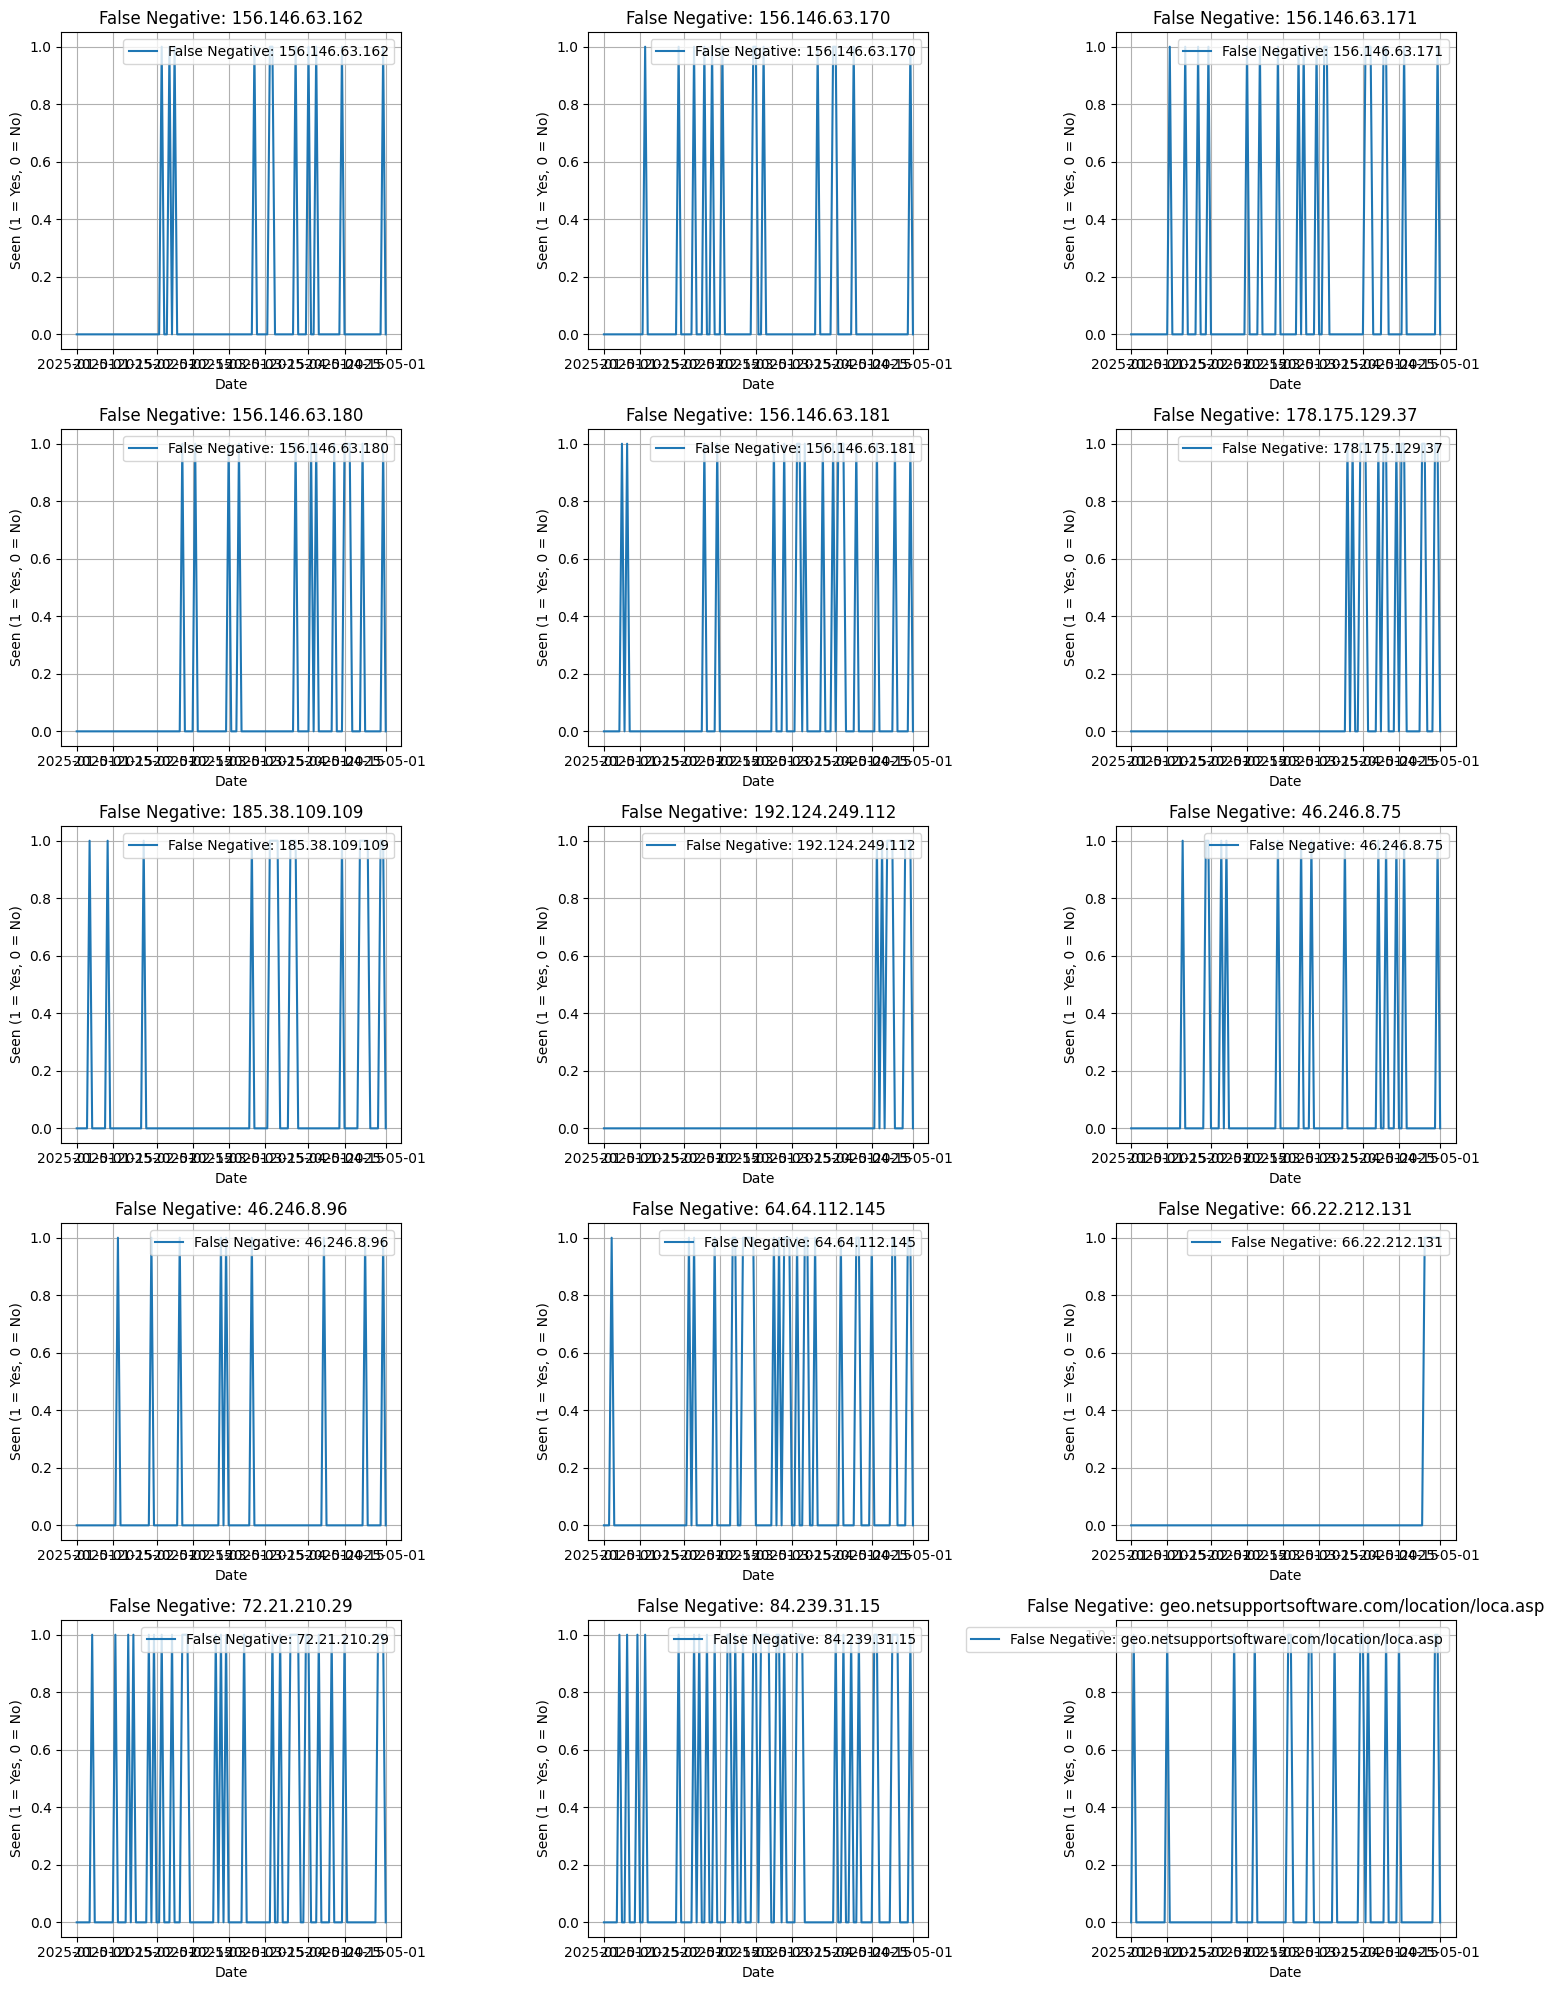

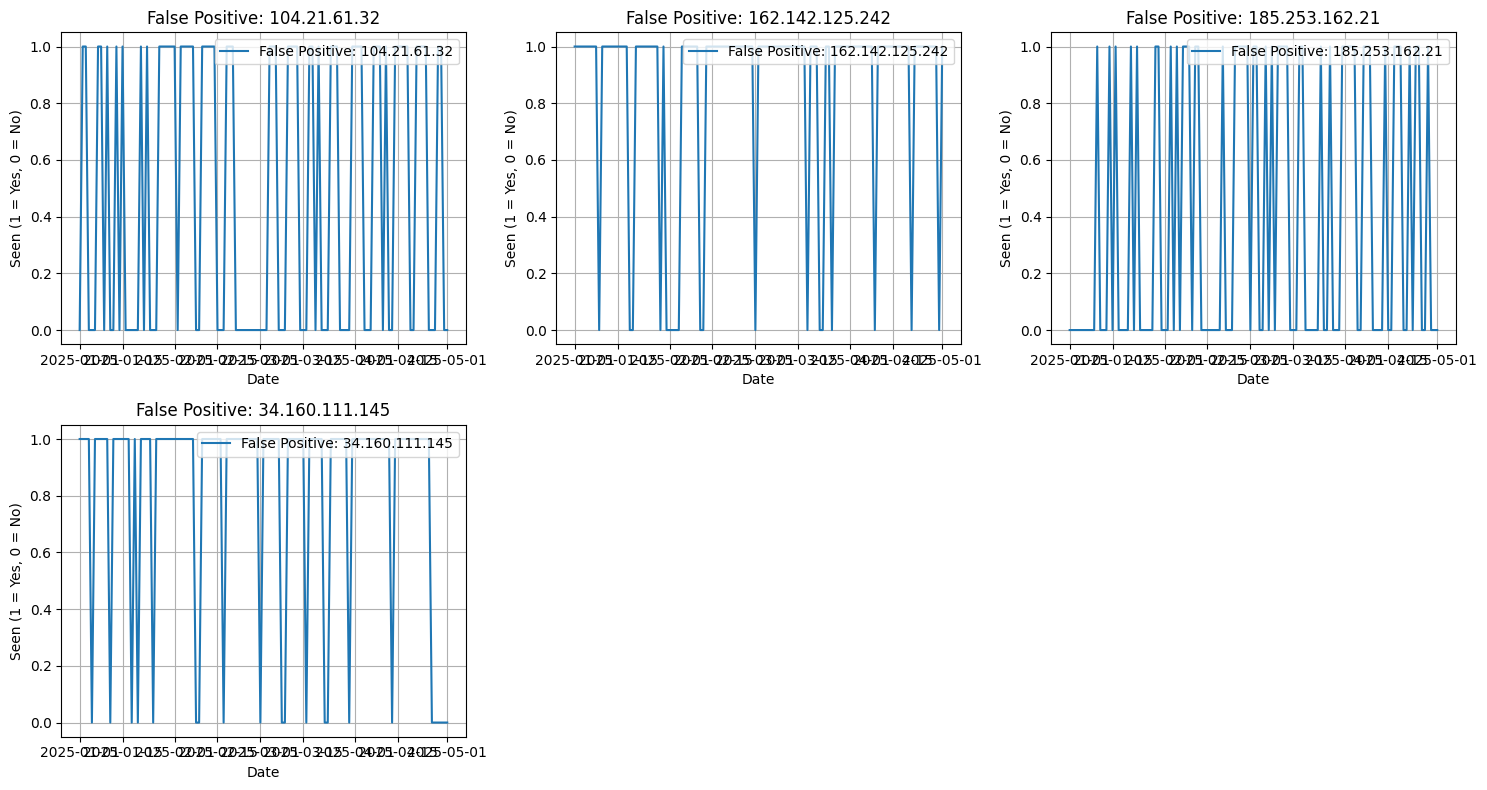

In [77]:
import matplotlib.pyplot as plt
import math

# Function to plot indicators in a grid
def plot_indicators_in_grid(activity_data, indicators, title_prefix):
    num_indicators = len(indicators)
    cols = 3  # Number of columns in the grid
    rows = math.ceil(num_indicators / cols)  # Calculate rows needed

    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
    axes = axes.flatten()  # Flatten the axes array for easy iteration

    for i, indicator in enumerate(indicators):
        ax = axes[i]
        indicator_data = activity_data[activity_data['indicator'] == indicator]
        ax.plot(indicator_data['date'], indicator_data['seen'], label=f'{title_prefix}: {indicator}')
        ax.set_title(f'{title_prefix}: {indicator}')
        ax.set_xlabel('Date')
        ax.set_ylabel('Seen (1 = Yes, 0 = No)')
        ax.legend(loc='upper right')
        ax.grid(True)

    # Hide any unused subplots
    for i in range(len(indicators), len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

# Plot false positives in a grid
plot_indicators_in_grid(false_negatives_activity, false_negatives['indicator'].unique(), 'False Negative')
plot_indicators_in_grid(false_positives_activity, false_positives['indicator'].unique(), 'False Positive')



In [78]:
#Pull records of false positives and false negatives
false_positives_records = df[df['indicator'].isin(false_positives['indicator'])]
false_negatives_records = df[df['indicator'].isin(false_negatives['indicator'])]

#merge the two dataframes to get all records
all_records = pd.concat([false_positives_records, false_negatives_records], ignore_index=True)
all_records = all_records.sort_values(by=['indicator', 'date']).reset_index(drop=True)
all_records['date'] = pd.to_datetime(all_records['date'])

all_records

,indicator,date,seen,cumulative_seen,days_since_last_seen_x,seen_streak,rolling_seen_ratio_14d,rolling_seen_std_14d,high_activity_not_seen_ratio_14d,low_activity_seen_ratio_14d,...,std_seen_interval,days_since_last_seen_y,high_activity_not_seen_count,high_activity_not_seen_ratio,low_activity_seen_count,low_activity_seen_ratio,seen_score,unseen_risk,seen_gap_mean,seen_gap_std
0,104.21.61.32,2025-01-01,0,0,0.0,0,0.000000,0.000000,1.000000,0.0,...,1.836462,2,0,0.000000,0,0.0,43.793388,3.20000,1.983051,1.852226
1,104.21.61.32,2025-01-02,1,1,0.0,1,0.500000,0.707107,0.500000,0.0,...,1.836462,2,0,0.000000,0,0.0,43.793388,3.20000,1.983051,1.852226
2,104.21.61.32,2025-01-03,1,2,0.0,2,0.666667,0.577350,0.333333,0.0,...,1.836462,2,0,0.000000,0,0.0,43.793388,3.20000,1.983051,1.852226
3,104.21.61.32,2025-01-04,0,2,1.0,0,0.500000,0.577350,0.250000,0.0,...,1.836462,2,0,0.000000,0,0.0,43.793388,3.20000,1.983051,1.852226
4,104.21.61.32,2025-01-05,0,2,2.0,0,0.400000,0.547723,0.200000,0.0,...,1.836462,2,0,0.000000,0,0.0,43.793388,3.20000,1.983051,1.852226
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2294,geo.netsupportsoftware.com/location/loca.asp,2025-04-27,0,14,12.0,0,0.071429,0.267261,0.928571,0.0,...,6.621849,1,105,0.867769,0,0.0,11.711570,92.27686,7.866667,6.854265
2295,geo.netsupportsoftware.com/location/loca.asp,2025-04-28,0,14,13.0,0,0.071429,0.267261,0.928571,0.0,...,6.621849,1,105,0.867769,0,0.0,11.711570,92.27686,7.866667,6.854265
2296,geo.netsupportsoftware.com/location/loca.asp,2025-04-29,1,15,0.0,1,0.071429,0.267261,0.928571,0.0,...,6.621849,1,105,0.867769,0,0.0,11.711570,92.27686,7.866667,6.854265
2297,geo.netsupportsoftware.com/location/loca.asp,2025-04-30,1,16,0.0,2,0.142857,0.363137,0.857143,0.0,...,6.621849,1,105,0.867769,0,0.0,11.711570,92.27686,7.866667,6.854265


In [79]:
false_negatives_records

,indicator,date,seen,cumulative_seen,days_since_last_seen_x,seen_streak,rolling_seen_ratio_14d,rolling_seen_std_14d,high_activity_not_seen_ratio_14d,low_activity_seen_ratio_14d,...,std_seen_interval,days_since_last_seen_y,high_activity_not_seen_count,high_activity_not_seen_ratio,low_activity_seen_count,low_activity_seen_ratio,seen_score,unseen_risk,seen_gap_mean,seen_gap_std
3267,156.146.63.162,2025-01-01,0,0,0.0,0,0.000000,0.000000,1.000000,0.0,...,8.616264,1,110,0.909091,0,0.0,8.145455,98.009091,8.600000,9.082339
3268,156.146.63.162,2025-01-02,0,0,0.0,0,0.000000,0.000000,1.000000,0.0,...,8.616264,1,110,0.909091,0,0.0,8.145455,98.009091,8.600000,9.082339
3269,156.146.63.162,2025-01-03,0,0,0.0,0,0.000000,0.000000,1.000000,0.0,...,8.616264,1,110,0.909091,0,0.0,8.145455,98.009091,8.600000,9.082339
3270,156.146.63.162,2025-01-04,0,0,0.0,0,0.000000,0.000000,1.000000,0.0,...,8.616264,1,110,0.909091,0,0.0,8.145455,98.009091,8.600000,9.082339
3271,156.146.63.162,2025-01-05,0,0,0.0,0,0.000000,0.000000,1.000000,0.0,...,8.616264,1,110,0.909091,0,0.0,8.145455,98.009091,8.600000,9.082339
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24437,geo.netsupportsoftware.com/location/loca.asp,2025-04-27,0,14,12.0,0,0.071429,0.267261,0.928571,0.0,...,6.621849,1,105,0.867769,0,0.0,11.711570,92.276860,7.866667,6.854265
24438,geo.netsupportsoftware.com/location/loca.asp,2025-04-28,0,14,13.0,0,0.071429,0.267261,0.928571,0.0,...,6.621849,1,105,0.867769,0,0.0,11.711570,92.276860,7.866667,6.854265
24439,geo.netsupportsoftware.com/location/loca.asp,2025-04-29,1,15,0.0,1,0.071429,0.267261,0.928571,0.0,...,6.621849,1,105,0.867769,0,0.0,11.711570,92.276860,7.866667,6.854265
24440,geo.netsupportsoftware.com/location/loca.asp,2025-04-30,1,16,0.0,2,0.142857,0.363137,0.857143,0.0,...,6.621849,1,105,0.867769,0,0.0,11.711570,92.276860,7.866667,6.854265


In [80]:
false_positives_records

,indicator,date,seen,cumulative_seen,days_since_last_seen_x,seen_streak,rolling_seen_ratio_14d,rolling_seen_std_14d,high_activity_not_seen_ratio_14d,low_activity_seen_ratio_14d,...,std_seen_interval,days_since_last_seen_y,high_activity_not_seen_count,high_activity_not_seen_ratio,low_activity_seen_count,low_activity_seen_ratio,seen_score,unseen_risk,seen_gap_mean,seen_gap_std
1210,104.21.61.32,2025-01-01,0,0,0.0,0,0.000000,0.000000,1.000000,0.000000,...,1.836462,2,0,0.0,0,0.00000,43.793388,3.2,1.983051,1.852226
1211,104.21.61.32,2025-01-02,1,1,0.0,1,0.500000,0.707107,0.500000,0.000000,...,1.836462,2,0,0.0,0,0.00000,43.793388,3.2,1.983051,1.852226
1212,104.21.61.32,2025-01-03,1,2,0.0,2,0.666667,0.577350,0.333333,0.000000,...,1.836462,2,0,0.0,0,0.00000,43.793388,3.2,1.983051,1.852226
1213,104.21.61.32,2025-01-04,0,2,1.0,0,0.500000,0.577350,0.250000,0.000000,...,1.836462,2,0,0.0,0,0.00000,43.793388,3.2,1.983051,1.852226
1214,104.21.61.32,2025-01-05,0,2,2.0,0,0.400000,0.547723,0.200000,0.000000,...,1.836462,2,0,0.0,0,0.00000,43.793388,3.2,1.983051,1.852226
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14999,34.160.111.145,2025-04-27,0,99,2.0,0,0.857143,0.363137,0.000000,0.214286,...,0.444786,6,0,0.0,9,0.07438,72.609091,4.2,1.163265,0.447072
15000,34.160.111.145,2025-04-28,0,99,3.0,0,0.785714,0.425815,0.000000,0.214286,...,0.444786,6,0,0.0,9,0.07438,72.609091,4.2,1.163265,0.447072
15001,34.160.111.145,2025-04-29,0,99,4.0,0,0.714286,0.468807,0.000000,0.142857,...,0.444786,6,0,0.0,9,0.07438,72.609091,4.2,1.163265,0.447072
15002,34.160.111.145,2025-04-30,0,99,5.0,0,0.642857,0.497245,0.000000,0.142857,...,0.444786,6,0,0.0,9,0.07438,72.609091,4.2,1.163265,0.447072


In [90]:
import pandas as pd


# Define logic to classify high-likelihood missed indicators
def label_high_likelihood(row):
    return (
        row['unseen_risk'] >= 80 and
        row['seen_score'] >= 7 and
        row['high_activity_not_seen_ratio'] >= 0.80 and
        row['seen_gap_mean'] <= 10 and
        row['seen_streak'] >= 1
    )


# Apply rule-based label
false_negatives['high_likelihood'] = false_negatives.apply(label_high_likelihood, axis=1)

# Filter and optionally save results
high_likelihood_fns = false_negatives[false_negatives['high_likelihood'] == True]
high_likelihood_fns.to_csv("high_likelihood_false_negatives.csv", index=False)

# Aggregate key metrics by indicator
aggregated = high_likelihood_fns.groupby('indicator').agg({
    'seen_score': 'mean',
    'unseen_risk': 'mean',
    'high_activity_not_seen_ratio': 'mean',
    'seen_gap_mean': 'mean',
    'seen_streak': 'max'
}).reset_index()

# Show summary
aggregated


C:\Users\jaskew\AppData\Local\Temp\ipykernel_17916\4038096087.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  false_negatives['high_likelihood'] = false_negatives.apply(label_high_likelihood, axis=1)


,indicator,seen_score,unseen_risk,high_activity_not_seen_ratio,seen_gap_mean,seen_streak
0,156.146.63.162,8.145455,98.009091,0.909091,8.600000,1.0
1,156.146.63.170,10.285124,93.129752,0.884298,7.923077,1.0
2,156.146.63.171,14.051240,87.797521,0.842975,5.777778,1.0
3,156.146.63.180,9.771901,97.956198,0.892562,6.500000,1.0
4,156.146.63.181,13.338017,91.423967,0.851240,6.588235,1.0
5,178.175.129.37,11.198347,104.903306,0.876033,2.500000,2.0
6,185.38.109.109,13.538017,93.823967,0.851240,6.705882,2.0
7,46.246.8.75,10.285124,92.929752,0.884298,7.615385,1.0
8,geo.netsupportsoftware.com/location/loca.asp,11.711570,92.276860,0.867769,7.866667,2.0


In [86]:
false_negatives

,indicator,forecast date,predicted seen,confidence,date,seen,cumulative_seen,days_since_last_seen_x,seen_streak,rolling_seen_ratio_14d,...,days_since_last_seen_y,high_activity_not_seen_count,high_activity_not_seen_ratio,low_activity_seen_count,low_activity_seen_ratio,seen_score,unseen_risk,seen_gap_mean,seen_gap_std,_merge
3,156.146.63.162,NaN,NaN,NaN,2025-04-30,1.0,11.0,0.0,1.0,0.071429,...,1.0,110.0,0.909091,0.0,0.0,8.145455,98.009091,8.600000,9.082339,right_only
4,156.146.63.170,NaN,NaN,NaN,2025-04-30,1.0,14.0,0.0,1.0,0.071429,...,1.0,107.0,0.884298,0.0,0.0,10.285124,93.129752,7.923077,7.041088,right_only
5,156.146.63.171,NaN,NaN,NaN,2025-04-30,1.0,19.0,0.0,1.0,0.142857,...,1.0,102.0,0.842975,0.0,0.0,14.051240,87.797521,5.777778,4.531661,right_only
6,156.146.63.180,NaN,NaN,NaN,2025-04-30,1.0,13.0,0.0,1.0,0.214286,...,1.0,108.0,0.892562,0.0,0.0,9.771901,97.956198,6.500000,5.900693,right_only
7,156.146.63.181,NaN,NaN,NaN,2025-04-30,1.0,18.0,0.0,1.0,0.214286,...,1.0,103.0,0.851240,0.0,0.0,13.338017,91.423967,6.588235,7.770608,right_only
12,178.175.129.37,NaN,NaN,NaN,2025-04-30,1.0,15.0,0.0,2.0,0.357143,...,1.0,106.0,0.876033,0.0,0.0,11.198347,104.903306,2.500000,1.870829,right_only
15,185.38.109.109,NaN,NaN,NaN,2025-04-30,1.0,18.0,0.0,2.0,0.428571,...,1.0,103.0,0.851240,0.0,0.0,13.538017,93.823967,6.705882,10.384873,right_only
16,192.124.249.112,NaN,NaN,NaN,2025-04-30,1.0,8.0,0.0,3.0,0.571429,...,1.0,113.0,0.933884,0.0,0.0,6.205785,115.088430,1.857143,1.463850,right_only
18,46.246.8.75,NaN,NaN,NaN,2025-04-30,1.0,14.0,0.0,1.0,0.142857,...,1.0,107.0,0.884298,0.0,0.0,10.285124,92.929752,7.615385,5.737863,right_only
19,46.246.8.96,NaN,NaN,NaN,2025-04-30,1.0,9.0,0.0,1.0,0.142857,...,1.0,112.0,0.925620,0.0,0.0,6.519008,98.461983,12.875000,7.679983,right_only
